## Question 1
**What is Boosting in Machine Learning? Explain how it improves weak learners.**

Boosting is an ensemble learning technique that combines multiple weak learners (usually shallow decision trees) sequentially to build a strong predictive model. Each new model focuses on correcting the mistakes made by the previous models. By giving more attention to misclassified or high-error samples, boosting gradually reduces prediction errors and improves overall accuracy.

## Question 2
**What is the difference between AdaBoost and Gradient Boosting in terms of how models are trained?**

AdaBoost increases the weights of misclassified samples so that the next weak learner focuses more on them. Gradient Boosting trains each new model to predict the residual errors (negative gradients of the loss function) made by the previous model. AdaBoost uses sample reweighting, whereas Gradient Boosting optimizes a differentiable loss function.

## Question 3
**How does regularization help in XGBoost?**

XGBoost uses L1 (alpha) and L2 (lambda) regularization to penalize complex trees. Regularization reduces overfitting, improves generalization, and controls tree complexity by limiting unnecessary splits and large leaf weights.

## Question 4
**Why is CatBoost considered efficient for handling categorical data?**

CatBoost can handle categorical features directly without requiring extensive one-hot encoding. It uses ordered target statistics and ordered boosting to reduce target leakage and improve accuracy on datasets containing categorical variables.

## Question 5
**What are some real-world applications where boosting techniques are preferred over bagging methods?**

Boosting is widely used in credit risk assessment, fraud detection, customer churn prediction, recommendation systems, click-through-rate prediction, medical diagnosis, insurance claim prediction, and sales forecasting because it often provides higher predictive accuracy.

## Question 6
**Write a Python program to train an AdaBoost Classifier on the Breast Cancer dataset and print the model accuracy.**

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = AdaBoostClassifier(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.9649122807017544


## Question 7
**Write a Python program to train a Gradient Boosting Regressor on the California Housing dataset and evaluate R² score.**

In [2]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.7756446042829697


## Question 8
**Write a Python program to train an XGBoost Classifier, tune learning_rate using GridSearchCV, and print best parameters and accuracy.**

In [3]:
from xgboost import XGBClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    {'learning_rate':[0.01,0.05,0.1,0.2]},
    cv=5
)
grid.fit(X_train, y_train)

pred = grid.best_estimator_.predict(X_test)
print("Best Params:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, pred))

Best Params: {'learning_rate': 0.2}
Accuracy: 0.956140350877193


## Question 9
**Write a Python program to train a CatBoost Classifier and plot the confusion matrix using seaborn.**

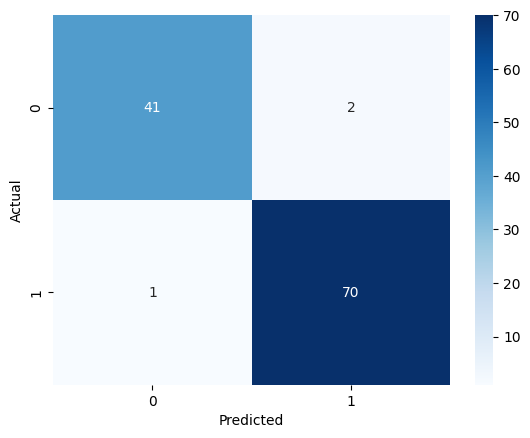

In [4]:
from catboost import CatBoostClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = CatBoostClassifier(verbose=0, random_state=42)
model.fit(X_train, y_train)

cm = confusion_matrix(y_test, model.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Question 10
**FinTech loan default prediction pipeline using boosting techniques.**

1. Split the data into train, validation, and test sets.
2. Handle missing values (median for numeric, mode for categorical).
3. Use CatBoost if many categorical features exist; otherwise XGBoost is a strong choice.
4. Handle class imbalance using class weights or scale_pos_weight (XGBoost).
5. Tune hyperparameters using RandomizedSearchCV or GridSearchCV with cross-validation.
6. Evaluate using Precision, Recall, F1-score, ROC-AUC, PR-AUC, and Confusion Matrix.
7. Select the best model and deploy it for predicting loan default risk.
Business benefits: lower default rates, improved credit decisions, reduced financial loss, and faster loan approval.